# 2D Skyrmions in `LambdaLLG`

This notebook follows a simple 2D skyrmion workflow.
We start from a painted Neel skyrmion seed, relax it with one choice of DMI, then switch the DMI pattern and relax again toward a Bloch-like texture.

To make the evolution easier to interpret, the notebook also extracts two scalar observables from the saved solution:

- an effective skyrmion radius, and
- an effective helicity.


In [ ]:
# Activate the package environment in the repository root.
using Pkg; Pkg.activate("../")

In [155]:
# Load the 2D LLG tools and plotting backend used throughout the notebook.
using LambdaLLG
using LinearAlgebra

import PyPlot as plt

## 1. Model Parameters

The first parameter set uses interfacial-type DMI vectors that favor a Neel-like skyrmion structure.
Later in the notebook these DMI vectors are changed to a bulk-like pattern to favor a Bloch-like texture instead.

In [73]:
# Lattice size and magnetic parameters.
Nx = 50
Ny = 50

J = 1.0
K = (0.0, 0.0, 0.15)
αG = 0.2
B_ext = (0.0, 0.0, -0.001)
dmix = (0.0, -0.2, 0.0)
dmiy = (0.2, 0.0, 0.0)

# Build the 2D parameter object.
par = LLGParams2D(
    Nx,                    # Number of sites x
    Ny,                    # Number of sites y
    J,                     # Heisenberg exchange
    K,                     # Anisotropy vector
    B_ext,                 # External field
    αG;                    # Gilbert damping
    D = (dmix, dmiy)       # DMI interaction
    );

## 2. Initial Skyrmion Seed

The initial state is a uniform background with a painted skyrmion at the center.
Setting `helicity = 0.0` produces a Neel-like seed.

In [74]:
# Start from a uniform ferromagnetic state and paint a centered skyrmion.
s0_neel = uniform_seed2D(Nx, Ny)      # Default direction is +z

paint_skyrmion2D!(s0_neel; radius = 10, helicity = 0.0)

normalize_spins!(s0_neel);

## 3. Relaxation with Two DMI Choices

The first solve relaxes the Neel-like seed.
Then the DMI vectors are changed and the relaxed texture is evolved again, allowing the same skyrmion to adapt toward a Bloch-like structure.

In [75]:
# Relax the Neel seed, then switch the DMI pattern and relax again.
t_relax = (0.0,500.0)

sol_neel = evolve2D(s0_neel, t_relax, par)

s_neel = reshape(sol_neel.u[end], 3, Nx, Ny)

dmix = (0.2, 0.0, 0.0)
dmiy = (0.0, 0.2, 0.0)
par.D = (dmix, dmiy)

sol_bloch = evolve2D(s_neel, t_relax, par)

s_bloch = reshape(sol_bloch.u[end], 3, Nx, Ny);

## 4. Tracking Radius, Centers, and Helicity

The next cell defines several simple time-series observables.

The radius is estimated from the area of the core region where `m_z < 0`, converted into an equivalent circular radius.
The skyrmion centers are found from connected components of the core region `m_z < threshold`, so the same helper can track one skyrmion or several at once.
The helicity is estimated from the in-plane spin direction along the skyrmion wall, identified here by the band `|m_z| < mz_window`.
The total topological charge is estimated by summing the signed solid angle of the spin field over all lattice plaquettes.

In particular, `center_series(sol)` returns one entry per saved time step, and each entry is a vector of centers `[(x_1, y_1), (x_2, y_2), \ldots]` sorted from left to right.

In [156]:
# Estimate the skyrmion radius from the area of the m_z < threshold core.
core_radius(spins; threshold=0.0) = sqrt(count(<(threshold), spins[3, :, :]) / pi)

function radius_series(sol; threshold=0.0)
    Nx = sol.prob.p.Nx
    Ny = sol.prob.p.Ny
    return [core_radius(reshape(u, 3, Nx, Ny); threshold=threshold) for u in sol.u]
end

# Find the centers of one or more skyrmion cores using connected components of the m_z < threshold region.
function skyrmion_centers(spins; threshold=0.0)
    Nx = size(spins, 2)
    Ny = size(spins, 3)
    mask = spins[3, :, :] .< threshold
    visited = falses(Nx, Ny)
    centers = Tuple{Float64, Float64}[]

    for j in 1:Ny, i in 1:Nx
        if !mask[i, j] || visited[i, j]
            continue
        end

        queue = [(i, j)]
        visited[i, j] = true
        head = 1
        wx = 0.0
        wy = 0.0
        total = 0.0

        while head <= length(queue)
            ci, cj = queue[head]
            head += 1

            w = max(0.0, 1.0 - spins[3, ci, cj])
            wx += w * ci
            wy += w * cj
            total += w

            for (ni, nj) in ((ci - 1, cj), (ci + 1, cj), (ci, cj - 1), (ci, cj + 1))
                if 1 <= ni <= Nx && 1 <= nj <= Ny && mask[ni, nj] && !visited[ni, nj]
                    visited[ni, nj] = true
                    push!(queue, (ni, nj))
                end
            end
        end

        if total > 0.0
            push!(centers, (wx / total, wy / total))
        end
    end

    sort!(centers, by = c -> (c[1], c[2]))
    return centers
end

# Apply the center finder to each saved state in the solution trajectory.
function center_series(sol; threshold=0.0)
    Nx = sol.prob.p.Nx
    Ny = sol.prob.p.Ny
    return [skyrmion_centers(reshape(u, 3, Nx, Ny); threshold=threshold) for u in sol.u]
end

# Estimate the skyrmion helicity from the in-plane spin direction along the wall.
function helicity_series(sol; mz_window=0.25)
    Nx = sol.prob.p.Nx
    Ny = sol.prob.p.Ny
    x0 = (Nx + 1) / 2
    y0 = (Ny + 1) / 2

    return [begin
        spins = reshape(u, 3, Nx, Ny)
        radial_sum = 0.0
        tangential_sum = 0.0
        count_wall = 0

        for j in 1:Ny, i in 1:Nx
            mz = spins[3, i, j]
            if abs(mz) < mz_window
                dx = i - x0
                dy = j - y0
                r = hypot(dx, dy)
                if r > 1e-12
                    ex = dx / r
                    ey = dy / r
                    mx = spins[1, i, j]
                    my = spins[2, i, j]
                    radial_sum += mx * ex + my * ey
                    tangential_sum += -mx * ey + my * ex
                    count_wall += 1
                end
            end
        end

        count_wall == 0 ? NaN : atan(tangential_sum / count_wall, radial_sum / count_wall)
    end for u in sol.u]
end

# Compute the total topological charge from the solid angle on each lattice plaquette.
triangle_solid_angle(a, b, c) = 2 * atan(
    dot(a, cross(b, c)),
    1 + dot(a, b) + dot(b, c) + dot(c, a)
)

function topological_charge(spins)
    Nx = size(spins, 2)
    Ny = size(spins, 3)
    omega = 0.0

    for j in 1:Ny-1, i in 1:Nx-1
        s1 = @view spins[:, i, j]
        s2 = @view spins[:, i + 1, j]
        s3 = @view spins[:, i + 1, j + 1]
        s4 = @view spins[:, i, j + 1]

        omega += triangle_solid_angle(s1, s2, s3)
        omega += triangle_solid_angle(s1, s3, s4)
    end

    return omega / (4 * pi)
end

# Apply the topological charge estimator to each saved state in the solution trajectory.
function topological_charge_series(sol)
    Nx = sol.prob.p.Nx
    Ny = sol.prob.p.Ny
    return [topological_charge(reshape(u, 3, Nx, Ny)) for u in sol.u]
end

topological_charge_series (generic function with 1 method)

## 5. Build Combined Time Series

The two solves are concatenated into one time axis so the radius and helicity can be viewed continuously across both relaxation stages.

In [77]:
# Combine the observables from the Neel-like and Bloch-like relaxation stages.
rad = vcat(radius_series(sol_neel), radius_series(sol_bloch))
hel = vcat(helicity_series(sol_neel), helicity_series(sol_bloch))

tt = vcat(sol_neel.t, sol_bloch.t .+ sol_neel.t[end]);

## 6. Compare the Textures

The first figure shows the initial seed, the relaxed Neel-like texture, and the later Bloch-like texture.
The color map displays `m_z`, while the quivers show the in-plane magnetization.

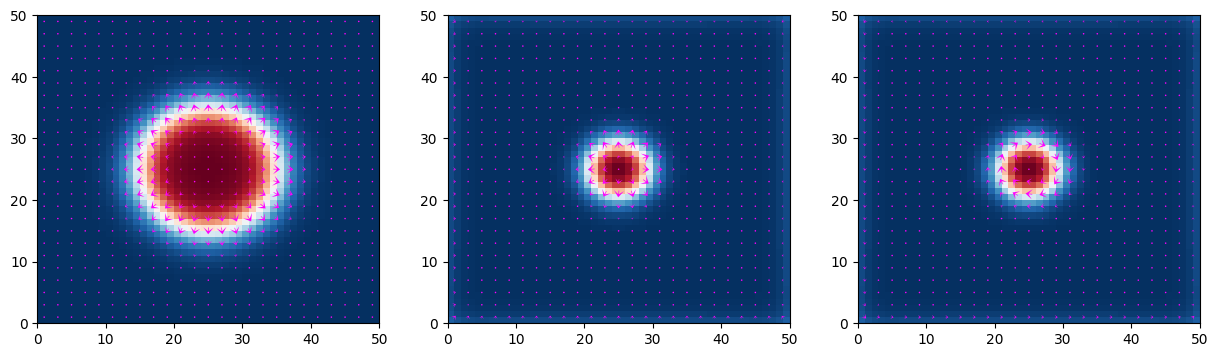

PyObject <matplotlib.quiver.Quiver object at 0x000002BE49A658D0>

In [78]:
# Plot m_z and the in-plane components for the initial, Neel-like, and Bloch-like textures.
fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(15,4))

ax[1].pcolormesh(s0_neel[3,:,:], cmap = "RdBu", vmin=-1, vmax=1)
ax[1].quiver(1:2:Ny, 1:2:Nx, s0_neel[2,1:2:end,1:2:end], s0_neel[1,1:2:end,1:2:end],
    color="magenta", pivot="mid", scale=50, headwidth=15, headlength=10, width=0.005)

ax[2].pcolormesh(s_neel[3,:,:], cmap = "RdBu", vmin=-1, vmax=1)
ax[2].quiver(1:2:Ny, 1:2:Nx, s_neel[2,1:2:end,1:2:end], s_neel[1,1:2:end,1:2:end],
    color="magenta", pivot="mid", scale=50, headwidth=15, headlength=10, width=0.005)

ax[3].pcolormesh(s_bloch[3,:,:], cmap = "RdBu", vmin=-1, vmax=1)
ax[3].quiver(1:2:Ny, 1:2:Nx, s_bloch[2,1:2:end,1:2:end], s_bloch[1,1:2:end,1:2:end],
    color="magenta", pivot="mid", scale=50, headwidth=15, headlength=10, width=0.005)

## 7. Radius and Helicity vs Time

The final plot overlays the effective radius and helicity on the same time axis.
This gives a compact view of how the skyrmion core size and internal winding evolve as the DMI convention is changed.

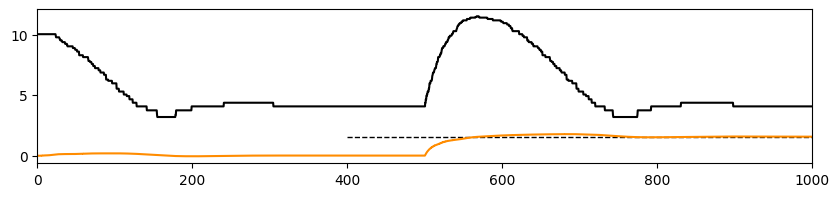

(0.0, 1000.0)

In [79]:
# Plot the radius and helicity extracted from the saved solution states.
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(10,2))

ax.plot(tt, rad, "k")
ax.plot(tt, hel, "darkorange")
ax.axhline(π/2, xmin=0.4, color="k", ls="--", lw=1, zorder=0)

ax.set_xlim(0,1000)

## 8. Driving Two Skyrmions with STT

This final example starts from a state containing two skyrmions, relaxes that pair at zero current, and then turns on spin-transfer torque to drive both textures across the sample.

The helper `center_series(sol_drive)` is useful here because it returns the skyrmion centers at each saved time, so the trajectories of multiple skyrmions can be plotted directly.

In [145]:
# Parameters for the two-skyrmion STT example.
Nx = 50
Ny = 100

J = 1.0
K = (0.0, 0.0, 0.15)
αG = 0.2
B_ext = (0.0, 0.0, -0.001)
dmix = (0.2, 0.0, 0.0)
dmiy = (0.0, 0.2, 0.0)

# Build the 2D parameter object.
par = LLGParams2D(
    Nx,                    # Number of sites x
    Ny,                    # Number of sites y
    J,                     # Heisenberg exchange
    K,                     # Anisotropy vector
    B_ext,                 # External field
    αG;                    # Gilbert damping
    D = (dmix, dmiy)       # DMI interaction
    );

In [146]:
# Paint two skyrmions into the same ferromagnetic background.
s0_2sk = uniform_seed2D(Nx, Ny)      # Default direction is +z

paint_skyrmion2D!(s0_2sk; radius = 5, helicity = π/2, center=(15,20))
paint_skyrmion2D!(s0_2sk; radius = 5, helicity = π/2, center=(35,20))

normalize_spins!(s0_2sk);

In [147]:
# Relax the pair first, then enable STT and drive the two-skyrmion texture.
t_relax = (0.0,300.0)
t_drive = (0.0,200.0)

sol_2sk = evolve2D(s0_2sk, t_relax, par)

s_2sk = reshape(sol_2sk.u[end], 3, Nx, Ny)

par.stt_active = true
par.u_stt = (0.1, 0.3)
par.beta_stt = 0.2

sol_drive = evolve2D(s_2sk, t_drive, par)

s_fin = reshape(sol_drive.u[end], 3, Nx, Ny);

In [158]:
# Reformat the tracked centers into x and y arrays for plotting the trajectories.
cen = center_series(sol_drive)

cenx = hcat([[p[1] for p in c] for c in cen]...)
ceny = hcat([[p[2] for p in c] for c in cen]...)

# Calculate the topological charge as a function of time
qs = topological_charge_series(sol_drive);

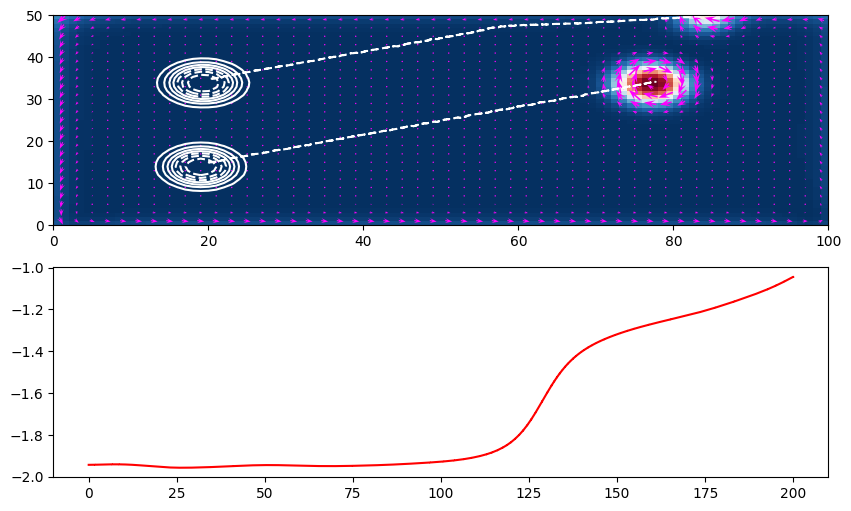

1-element Vector{PyCall.PyObject}:
 PyObject <matplotlib.lines.Line2D object at 0x000002BF735AF6D0>

In [160]:
# Overlay the driven skyrmion trajectories on the final out-of-plane texture.
# Note that the top skyrmion annihilates against the boundary so that the 
# topological charge drops by one.
fig, ax = plt.subplots(nrows=2, ncols=1, figsize=(10,6))

ax[1].contour(s_2sk[3,:,:], vmin=-1, vmax=1, colors="w")

ax[1].plot(ceny[1,:], cenx[1,:], "w--")
ax[1].plot(ceny[2,:], cenx[2,:], "w--")

ax[1].pcolormesh(s_fin[3,:,:], cmap = "RdBu", vmin=-1, vmax=1)
ax[1].quiver(1:2:Ny, 1:2:Nx, s_fin[2,1:2:end,1:2:end], s_fin[1,1:2:end,1:2:end],
    color="magenta", pivot="mid", scale=50, headwidth=5, headlength=7, width=0.002)

ax[2].plot(sol_drive.t, qs, "r")

## Summary

This notebook shows one of the basic 2D skyrmion workflows in `LambdaLLG`:

- paint a skyrmion seed,
- relax it under a chosen DMI pattern,
- switch the DMI pattern and relax again, and
- extract scalar observables such as radius and helicity from the full trajectory, and
- track the motion of one or more skyrmions under STT through their center coordinates.
